# 1. Test Pipeline on Fake Data

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

import json
from time import time
import copy
import random
import torch
from modules.utils.utils import save_json, load_json

from modules import (
    build_heterodata_from_json,
    attach_sample_values,
    HeteroImputer,
    train_imputer_one_sample,
    predict_nodes,
    generate_fake_sample_x,
)
from modules.preprocessing import *
from modules.utils.reproducibility import set_seed
from modules.visualization.plots import (
    plot_training_history,
    plot_selected_node_importance_grid
)

from modules.data.graph_builder import build_sample_graph_from_store, build_dataset_from_store
from modules.utils.dataset import infer_num_classes, split_dataset, make_loaders
from modules.models.hetero_model import MissingAwareHeteroClassifier
from modules.training.train import fit_model
from modules.explain.explainer import (
    explain_hetero_graph_with_gradients,
    explain_random_samples_and_average,
    summarize_top_nodes_with_missing_status,
    explain_all_samples_and_average
)

from modules.pipelines.baseline_pipeline import (
    prepare_dataset,
    train_pipeline,
    explain_sample,
    print_explanation_report,
    inspect_missing_nodes,
    plot_results,
)

from modules.data.graph_transform import GraphSubsampler
set_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


# 2. Generate Different ROSMAP Dataset Settings

Running experiment: enhancer_gene-miRNA_transcript_protein
Selected node types: ['Enhancer', 'gene', 'miRNA', 'transcript', 'protein']
Removed node types: ['R', 'Promoter', 'Promoter/Enhancer', 'protein_complex']
Number of nodes: 20942
Number of edges: 56086

[START] Building sample store
omics_config: sample_id_col='Sample ID', label_col='Diagnosis', strict_sample_match=True, nan_policy='keep', coerce_numeric=True, drop_duplicates='error'
Omics provided: ['transcript', 'miRNA', 'gene', 'protein', 'Promoter', 'Promoter/Enhancer', 'Enhancer']

[READ] Omic='transcript' | file='../data/ROSMAP/gene_expression_data_scaled.csv'
  - Loaded shape: (155, 18589) (rows, cols)
  - First 5 columns: ['Sample ID', 'Gender', 'Race', 'PMI', 'Braak']
  - No duplicated 'Sample ID' values found.
  - Applied suffix '_transcript' to 18583 feature columns
  - Unique sample IDs: 155
  - Label distribution:
AD         84
Control    71
Name: Diagnosis, dtype: int64

[READ] Omic='miRNA' | file='../data/ROSMAP/mi

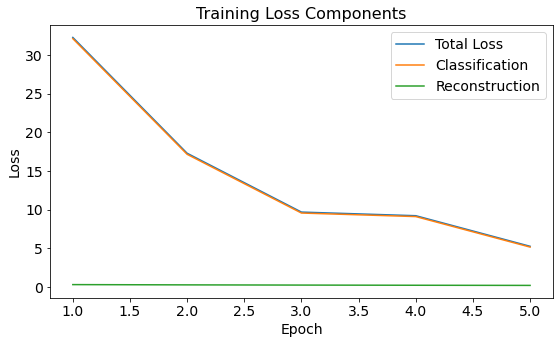

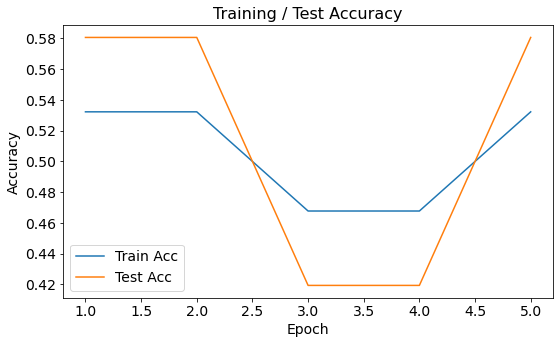

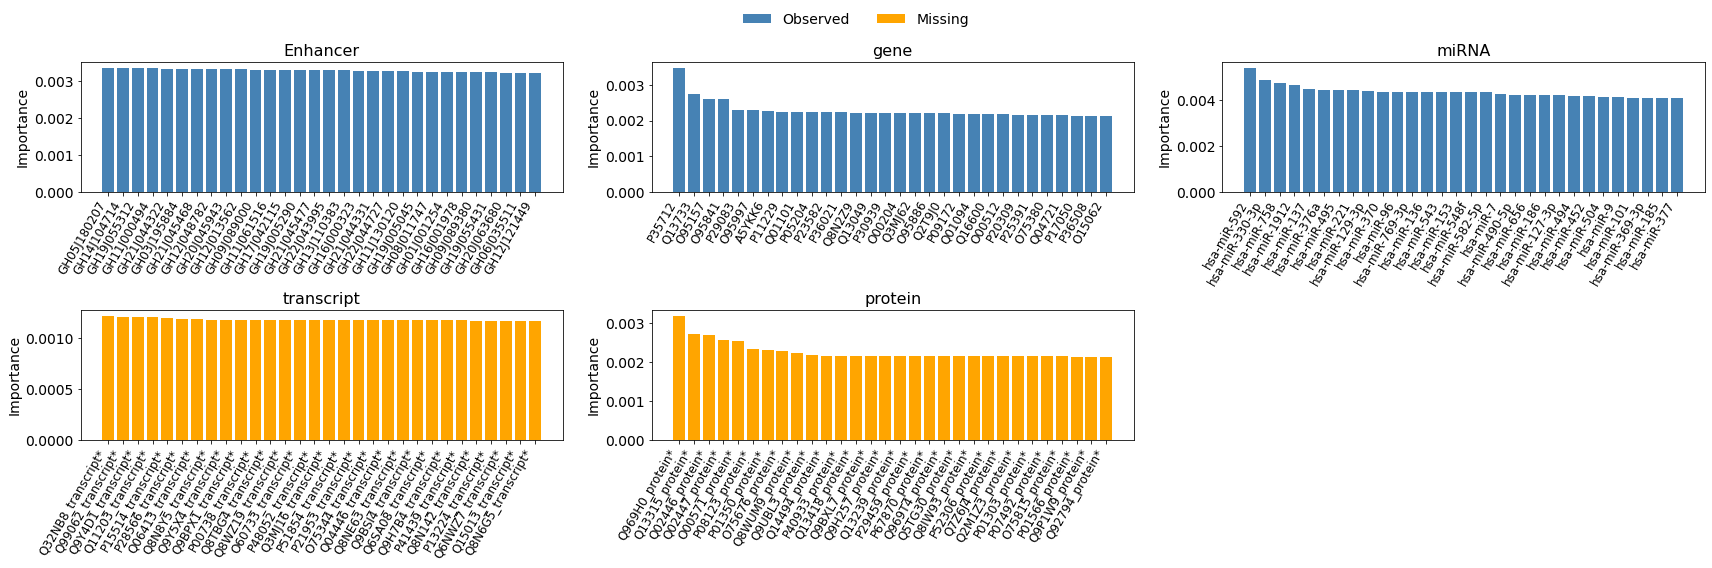

Saved figure to: ../RESULTS/ROSMAP/enhancer_gene_miRNA_transcript_protein/node_importance_R4174623.png

Average explanation across sampled test graphs
Number of sampled graphs: 10
Sample IDs: ['R9101835', 'R4022468', 'R2372487', 'R8882846', 'R4174623', 'R5334541', 'R2398607', 'R2167020', 'R2880377', 'R7141740']

Top average-important nodes for node type: gene
{'node_name': 'P06213', 'importance': 0.0022004039492458105}
{'node_name': 'Q16543', 'importance': 0.0021886841859668493}
{'node_name': 'P35712', 'importance': 0.0021683978848159313}
{'node_name': 'P33897', 'importance': 0.0021414640359580517}
{'node_name': 'P10176', 'importance': 0.002029002644121647}

Top average-important nodes for node type: transcript
{'node_name': 'Q32NB8_transcript', 'importance': 0.0011914910282939672}
{'node_name': 'Q99062_transcript', 'importance': 0.001184983877465129}
{'node_name': 'Q9Y4D1_transcript', 'importance': 0.0011798671912401915}
{'node_name': 'Q11203_transcript', 'importance': 0.0011794057209

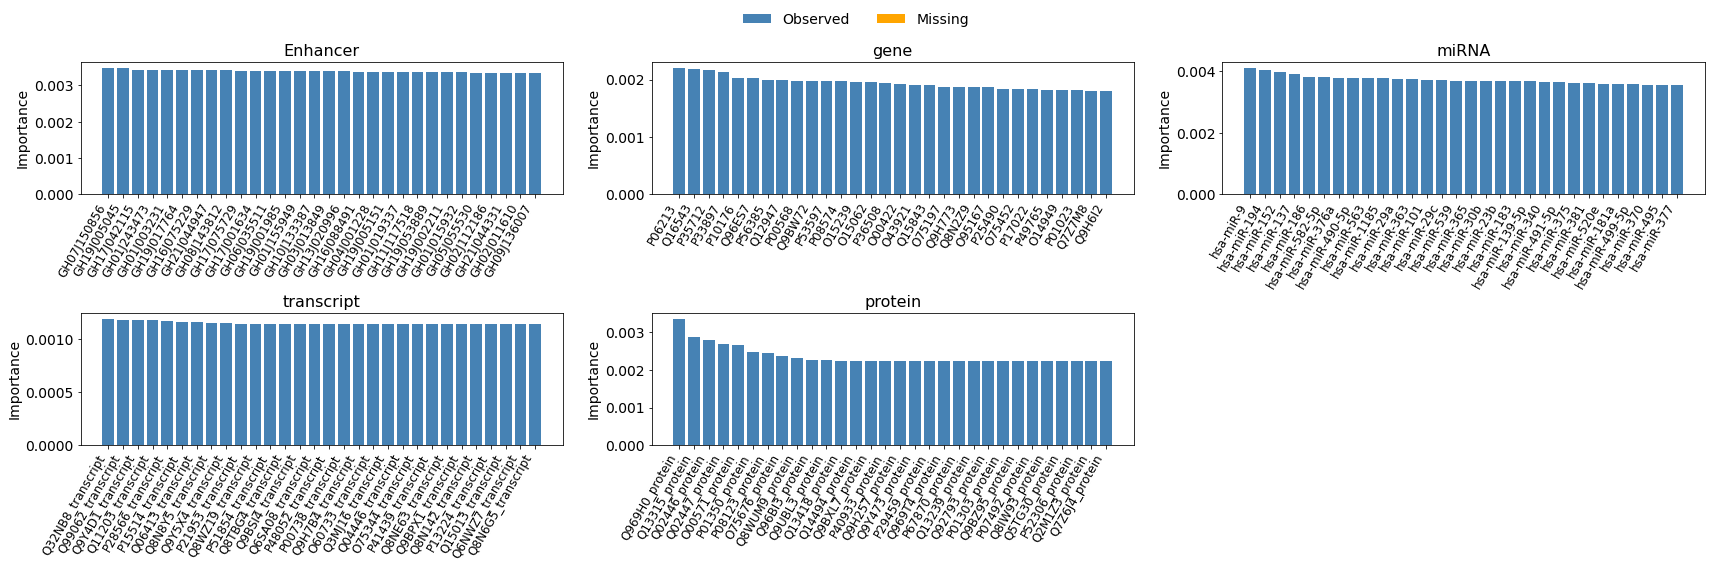

Saved figure to: ../RESULTS/ROSMAP/enhancer_gene_miRNA_transcript_protein/avg_node_importance.png
Saved model checkpoint to: ../RESULTS/ROSMAP/enhancer_gene_miRNA_transcript_protein/model.pt
Inference completed and saved.
Finished experiment: enhancer_gene-miRNA_transcript_protein

All experiment summaries:
- enhancer_gene-miRNA_transcript_protein: ../RESULTS/ROSMAP/enhancer_gene_miRNA_transcript_protein


In [2]:
import os
import json
import random
from copy import deepcopy
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Any

import pandas as pd
import torch

from modules.models.heads import (
    SimpleMLPHead,
    DeepMLPHead,
    ResidualMLPHead,
    GatedHead,
    build_head
)
import os


from modules.inference.prediction_utils import (
    save_model_checkpoint,
    run_full_inference,
)

# =========================================================
# Constants
# =========================================================
ALL_NODE_TYPES = [
    "R",
    "transcript",
    "gene",
    "protein",
    "Enhancer",
    "Promoter",
    "Promoter/Enhancer",
    "miRNA",
    "protein_complex",
]

DEFAULT_OMICS_CONFIG = {
    "transcript": "../data/ROSMAP/gene_expression_data_scaled.csv",
    "miRNA": "../data/ROSMAP/microRNA_scaled.csv",
    "gene": "../data/ROSMAP/gene_expression_data_scaled.csv",
    "protein": "../data/ROSMAP/gene_expression_data_scaled.csv",
    "Promoter": "../data/ROSMAP/methylation_regulatory_split/methylation_Promoter_aggregated.csv",
    "Promoter/Enhancer": "../data/ROSMAP/methylation_regulatory_split/methylation_Promoter_Enhancer_aggregated.csv",
    "Enhancer": "../data/ROSMAP/methylation_regulatory_split/methylation_Enhancer_aggregated.csv",
}

DEFAULT_FEATURE_SUFFIX_MAP = {
    "miRNA": "",
    "gene": "",
    "transcript": "_transcript",
    "protein": "_protein",
    "Promoter": "",
    "Promoter/Enhancer": "",
    "Enhancer": "",
}

DEFAULT_CFG = TabularOmicsConfig(
    sample_id_col="Sample ID",
    label_col="Diagnosis",
    strict_sample_match=True,
    drop_duplicates="error",
    coerce_numeric=True,
    nan_policy="keep",
    clinical_drop_cols=["Gender", "Race", "PMI", "Braak"],
)


# =========================================================
# Experiment config
# =========================================================
@dataclass
class ExperimentRunConfig:
    graph_path: str = "../artifacts/universalGraph_new.json"
    add_reverse: bool = True
    results_root: str = "../RESULTS/ROSMAP"
    stores_root: str = "../artifacts/experiment_stores"

    cfg: TabularOmicsConfig = DEFAULT_CFG
    omics_config: Dict[str, str] = field(default_factory=lambda: DEFAULT_OMICS_CONFIG)
    feature_suffix_map: Dict[str, str] = field(default_factory=lambda: DEFAULT_FEATURE_SUFFIX_MAP)

    unknown_node_keep_fraction: float = 0.1
    seed: int = 42

    num_classes: int = 2
    hidden_dim: int = 64
    num_layers: int = 2
    dropout: float = 0.3
    batch_size: int = 32
    epochs: int = 20
    lr: float = 1e-3
    train_frac: float = 0.8
    num_nodes_to_plot: int = 50
    explanation_sample_k: int = 10
    head_type: str = "type_aware"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


# =========================================================
# Helpers
# =========================================================
def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def sanitize_name(name: str) -> str:
    return (
        name.replace("/", "_")
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("-", "_")
    )


def load_graph_json(graph_path: str) -> Dict[str, Any]:
    with open(graph_path, "r") as f:
        return json.load(f)


def get_columns_to_exclude(cfg: TabularOmicsConfig) -> List[str]:
    return [cfg.sample_id_col, cfg.label_col] + cfg.clinical_drop_cols


def build_known_nodes_by_type(
    omics_config: Dict[str, str],
    cfg: TabularOmicsConfig,
    feature_suffix_map: Dict[str, str],
) -> Dict[str, List[str]]:
    """
    Reads all omics tables and extracts feature names that correspond
    to known graph nodes for each omic type.
    """
    columns_to_exclude = get_columns_to_exclude(cfg)

    known_nodes_by_type = {omic_type: [] for omic_type in omics_config.keys()}

    for omic_type, file_path in omics_config.items():
        df = pd.read_csv(file_path)

        feature_columns = [c for c in df.columns if c not in columns_to_exclude]
        suffix = feature_suffix_map.get(omic_type, "")
        renamed_features = [f"{feature}{suffix}" for feature in feature_columns]

        known_nodes_by_type[omic_type] = renamed_features

    return known_nodes_by_type


def get_removed_node_types_from_selected(selected_node_types: List[str]) -> List[str]:
    return [node_type for node_type in ALL_NODE_TYPES if node_type not in selected_node_types]


def build_filtered_graph_json(
    base_graph_json: Dict[str, Any],
    omic_types_to_remove: List[str],
    known_nodes_by_type: Dict[str, List[str]],
    unknown_node_keep_fraction: float,
) -> Dict[str, Any]:
    graph_transformer = GraphSubsampler(deepcopy(base_graph_json))

    graph_transformer = (
        graph_transformer
        .exclude_omic_types(
            omic_types_to_exclude=omic_types_to_remove,
            make_copy=False,
        )
        .sample_unknown_nodes(
            known_nodes_by_type=known_nodes_by_type,
            unknown_node_keep_fraction=unknown_node_keep_fraction,
            make_copy=False,
        )
    )

    return graph_transformer.graph_json


def build_store(
    omics_config: Dict[str, str],
    cfg: TabularOmicsConfig,
) -> Dict[str, Any]:
    return build_sample_store_from_configs(omics_config, cfg)


def save_experiment_store(
    store: Dict[str, Any],
    stores_root: str,
    experiment_name: str,
) -> Path:
    os.makedirs(stores_root, exist_ok=True)
    store_path = Path(stores_root) / f"{sanitize_name(experiment_name)}_store.json"
    save_json(store_path, store)
    return store_path


def prepare_experiment_data(
    hd,
    store_path: Path,
    run_cfg: ExperimentRunConfig,
):
    return prepare_dataset(
        hd=hd,
        store_path=store_path,
        train_frac=run_cfg.train_frac,
        batch_size=run_cfg.batch_size,
        seed=run_cfg.seed,
    )


def build_model_head(train_dataset, run_cfg: ExperimentRunConfig):
    num_types = len(train_dataset[0].node_types)
    graph_emb_dim = run_cfg.hidden_dim * num_types

    head = build_head(
        head_type=run_cfg.head_type,
        input_dim=graph_emb_dim,
        out_dim=run_cfg.num_classes,
        hidden_dim=run_cfg.hidden_dim,
        num_types=num_types,
        dropout=run_cfg.dropout,
    )
    return head


# =========================================================
# Core experiment runner
# =========================================================
def run_single_experiment(
    experiment_name: str,
    selected_node_types: List[str],
    run_cfg: ExperimentRunConfig,
    base_graph_json: Dict[str, Any],
    known_nodes_by_type: Dict[str, List[str]],
) -> Dict[str, Any]:
    print("=" * 80)
    print(f"Running experiment: {experiment_name}")
    print(f"Selected node types: {selected_node_types}")

    exp_dir = Path(run_cfg.results_root) / sanitize_name(experiment_name)
    os.makedirs(exp_dir, exist_ok=True)

    omic_types_to_remove = get_removed_node_types_from_selected(selected_node_types)
    print(f"Removed node types: {omic_types_to_remove}")

    filtered_graph_json = build_filtered_graph_json(
        base_graph_json=base_graph_json,
        omic_types_to_remove=omic_types_to_remove,
        known_nodes_by_type=known_nodes_by_type,
        unknown_node_keep_fraction=run_cfg.unknown_node_keep_fraction,
    )

    print("Number of nodes:", len(filtered_graph_json["vertices"]))
    print("Number of edges:", len(filtered_graph_json["edges"]))

    hd = build_heterodata_from_json(filtered_graph_json, add_reverse=run_cfg.add_reverse)

    store = build_store(
        omics_config=run_cfg.omics_config,
        cfg=run_cfg.cfg,
    )
    store_path = save_experiment_store(
        store=store,
        stores_root=run_cfg.stores_root,
        experiment_name=experiment_name,
    )

    prepared = prepare_experiment_data(
        hd=hd,
        store_path=store_path,
        run_cfg=run_cfg,
    )

    train_dataset = prepared["train_dataset"]
    test_dataset = prepared["test_dataset"]
    train_loader = prepared["train_loader"]
    test_loader = prepared["test_loader"]
    missing_tracker = prepared["missing_tracker"]

    head = build_model_head(train_dataset, run_cfg)

    model, history = train_pipeline(
        train_loader=train_loader,
        test_loader=test_loader,
        metadata=train_dataset[0].metadata(),
        device=run_cfg.device,
        hidden_dim=run_cfg.hidden_dim,
        num_layers=run_cfg.num_layers,
        dropout=run_cfg.dropout,
        lr=run_cfg.lr,
        epochs=run_cfg.epochs,
        head=head,
    )

    # -----------------------------------------------------
    # Single-sample explanation
    # -----------------------------------------------------
    example = test_dataset[0]
    sample_id, result, top_summary = explain_sample(
        model=model,
        sample=example,
        missing_tracker=missing_tracker,
        device=run_cfg.device,
        top_k=run_cfg.num_nodes_to_plot,
    )

    print_explanation_report(
        sample=example,
        sample_id=sample_id,
        result=result,
        top_summary=top_summary,
        preview_top_n=5,
    )

    inspect_missing_nodes(
        sample=example,
        sample_id=sample_id,
        missing_tracker=missing_tracker,
        node_type=None,
        preview_n=run_cfg.num_nodes_to_plot,
    )

    plot_results(
        history=history,
        sample=example,
        sample_id=sample_id,
        result=result,
        missing_tracker=missing_tracker,
        training_save_path=str(exp_dir / "training_curve.png"),
        training_figsize=(8, 5),
        node_types_to_plot=selected_node_types,
        node_top_k=run_cfg.num_nodes_to_plot,
        node_plot_save_path=str(exp_dir / f"node_importance_{sample_id}.png"),
        node_plot_figsize=(24, 8),
        dpi=300,
    )

    # -----------------------------------------------------
    # Average explanation
    # -----------------------------------------------------
    average_explanations = explain_random_samples_and_average(
        model=model,
        dataset=test_dataset,
        device=run_cfg.device,
        k=run_cfg.explanation_sample_k,
        top_k=run_cfg.num_nodes_to_plot,
    )

    save_json(exp_dir / "average_explanations.json", average_explanations)

    print("\nAverage explanation across sampled test graphs")
    print(f"Number of sampled graphs: {average_explanations['n_samples']}")
    print(f"Sample IDs: {average_explanations['sampled_sample_ids']}")

    for node_type, rows in average_explanations["avg_top_summary"].items():
        print(f"\nTop average-important nodes for node type: {node_type}")
        for row in rows[:5]:
            print(row)

    reference_sample = test_dataset[0]
    avg_node_importance_tensors = {
        node_type: torch.tensor(values, dtype=torch.float32)
        for node_type, values in average_explanations["avg_node_importance"].items()
    }

    plot_selected_node_importance_grid(
        data=reference_sample,
        node_importance=avg_node_importance_tensors,
        missing_nodes_for_sample={},
        selected_node_types=selected_node_types,
        top_k=run_cfg.num_nodes_to_plot,
        save_path=str(exp_dir / "avg_node_importance.png"),
        dpi=300,
        figsize=(24, 8),
    )

    # -----------------------------------------------------
    # Save model + inference
    # -----------------------------------------------------
    save_model_checkpoint(
        model=model,
        save_path=str(exp_dir / "model.pt"),
        metadata=train_dataset[0].metadata(),
        config={
            "head_type": run_cfg.head_type,
            "selected_node_types": selected_node_types,
            "removed_node_types": omic_types_to_remove,
        },
    )

    run_full_inference(
        model=model,
        prepared=prepared,
        device=run_cfg.device,
        output_dir=str(exp_dir),
        save_json=save_json,
    )

    # -----------------------------------------------------
    # Collect summary
    # -----------------------------------------------------
    summary = {
        "experiment_name": experiment_name,
        "selected_node_types": selected_node_types,
        "removed_node_types": omic_types_to_remove,
        "n_vertices": len(filtered_graph_json["vertices"]),
        "n_edges": len(filtered_graph_json["edges"]),
        "output_dir": str(exp_dir),
        "store_path": str(store_path),
    }

    save_json(exp_dir / "experiment_summary.json", summary)
    print(f"Finished experiment: {experiment_name}")
    return summary


def run_experiment_suite(
    experiments: Dict[str, List[str]],
    run_cfg: ExperimentRunConfig,
) -> Dict[str, Any]:
    set_seed(run_cfg.seed)

    os.makedirs(run_cfg.results_root, exist_ok=True)
    os.makedirs(run_cfg.stores_root, exist_ok=True)

    base_graph_json = load_graph_json(run_cfg.graph_path)
    known_nodes_by_type = build_known_nodes_by_type(
        omics_config=run_cfg.omics_config,
        cfg=run_cfg.cfg,
        feature_suffix_map=run_cfg.feature_suffix_map,
    )

    all_results = {}

    for experiment_name, selected_node_types in experiments.items():
        summary = run_single_experiment(
            experiment_name=experiment_name,
            selected_node_types=selected_node_types,
            run_cfg=run_cfg,
            base_graph_json=base_graph_json,
            known_nodes_by_type=known_nodes_by_type,
        )
        all_results[experiment_name] = summary

    save_json(Path(run_cfg.results_root) / "all_experiments_summary.json", all_results)
    return all_results


# =========================================================
# Example usage
# =========================================================
if __name__ == "__main__":
    experiments = {
        # "transcript_protein": ["transcript", "protein"],
        # "gene_transcript": ["gene","transcript"],
        # "gene_transcript_protein": ["gene","transcript", "protein"],
        # "miRNA_transcript_protein": ["miRNA","transcript", "protein"],
        # "miRNA__transcript": ["miRNA","transcript"],
        # "gene_miRNA_transcript": ["gene", "miRNA", "transcript"],
        # "transcript_miRNA_only": ["transcript", "miRNA"],
        "enhancer_gene-miRNA_transcript_protein": ["Enhancer","gene","miRNA","transcript", "protein"],
        # "promoter_enhancer_gene-miRNA_transcript_protein": ["Promoter","Enhancer","gene","miRNA","transcript", "protein"],
        # "full_network": ["Promoter/Enhancer","Promoter","Enhancer","gene","miRNA","transcript", "protein"],
    }

    run_cfg = ExperimentRunConfig(
        graph_path="../artifacts/universalGraph_new.json",
        add_reverse=True,
        results_root="../RESULTS/ROSMAP",
        stores_root="../artifacts/experiment_stores",
        unknown_node_keep_fraction=0.1,
        seed=42,
        num_classes=2,
        hidden_dim=64,
        num_layers=2,
        dropout=0.1,
        batch_size=32,
        epochs=5,
        lr=1e-3,
        train_frac=0.8,
        num_nodes_to_plot=30,
        explanation_sample_k=10,
        head_type="type_aware",
    )

    results = run_experiment_suite(
        experiments=experiments,
        run_cfg=run_cfg,
    )

    print("\nAll experiment summaries:")
    for exp_name, exp_summary in results.items():
        print(f"- {exp_name}: {exp_summary['output_dir']}")

In [3]:
0

0